# Search and highlight — `repo.search()` + `fig.show()`

This notebook demonstrates finding exact sequences in a pangenome graph and
highlighting the matched nodes directly in the interactive viewer.

**Workflow:**
1. Import the Anderson promoter GFA
2. Open the interactive graph widget
3. Search without an index — `search()` falls back to a full scan
4. Build a seed index, search again with the same call — now accelerated
5. Highlight multiple motifs in different colours
6. Search across multiple block groups
7. Freeze the widget for static distribution

## Setup

We import the [Anderson promoter collection](http://parts.igem.org/Promoters/Catalog/Anderson)
as a GFA, giving us a proper sequence graph with shared nodes and junctions.

In [1]:
import pathlib
import tempfile

import gen

REPO_ROOT = pathlib.Path(gen.__file__).parents[3]
GFA = REPO_ROOT / "fixtures" / "anderson_promoters.gfa"
assert GFA.exists(), f"Fixture not found: {GFA}"
FASTA = REPO_ROOT / "fixtures" / "anderson_promoters.fa"
assert FASTA.exists(), f"Fixture not found: {FASTA}"


WORK_DIR = pathlib.Path(tempfile.mkdtemp(prefix="gen-search-"))
print(f"Working in {WORK_DIR}")

repo = gen.Repository(str(WORK_DIR))
repo.import_gfa(str(GFA), sample='pooled', collection='anderson')
repo.import_fasta(str(FASTA))

bgs = repo.get_sequence_graphs()
print(f"{len(bgs)} block group(s) imported")


Working in /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-search-gi91uvec
21 block group(s) imported


## Plot the graph

Calling `display(bg)` or ending a notebook cell with a block group variable will generate an interactive plot. You can configure parameters like size and details by explicitly calling `bg.plot(rows, cols, detail)`. This also allows you to store a reference to the figure, which then enables functions like `show()` and `clear_highlights()` to update
it **in place** in this cell without re-running it.


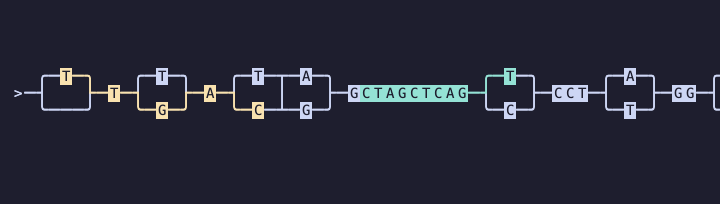

In [2]:
bg = bgs[0]
fig = bg.plot()
fig.show_path()
fig


## Search without an index

`repo.search()` works out of the box — no index required.  When no `.bin` file
is found for a block group it falls back to a full graph scan automatically.

The query `"ctagctcagt"` is the conserved **−10 box** core present in all
Anderson promoters.

**Case insensitivity** — By default, search is case-insensitive: `"ctagctcagt"` finds the
same results as `"CTAGCTCAGT"`.  Pass `sequence_kind="exact"` to search for exact case.

In [3]:
QUERY = "ctagctcagt"

matches = bg.search(QUERY)
print(f"Found {len(matches)} match(es) for {QUERY!r} (full scan)")

fig.clear_highlights()

for m in matches:
    fig.show(m)
    print(" ", m)

Found 1 match(es) for 'ctagctcagt' (full scan)
  GraphLocus(019df715[0..10]+1 → 019df715[0..1]+1, 2 blocks, strand=+)


In [4]:
MINUS_35 = "TTGACA"
hits_by_bg = repo.search(MINUS_35)

print(f"'{MINUS_35}' found in {len(hits_by_bg)} / {len(bgs)} block group(s)")
for b, hits in hits_by_bg:
    print(f"  {b.name:15s}  {len(hits)} hit(s)")

if len(hits_by_bg) > 1:
    bg2, hits2 = hits_by_bg[1]
    w2 = bg2.plot(detail='full')
    for m in hits2:
        w2.show(m, "yellow")
    w2.freeze()
    print(f"\nOpened {bg2.name!r} with {len(hits2)} highlight(s)")
    w2


'TTGACA' found in 6 / 21 block group(s)
                   1 hit(s)
  BBa_J23119       1 hit(s)
  BBa_J23102       1 hit(s)
  BBa_J23104       1 hit(s)
  BBa_J23116       1 hit(s)
  BBa_J23117       1 hit(s)

Opened 'BBa_J23119' with 1 highlight(s)


## Build a seed index

`repo.build_index()` saves a junction-aware k-mer index to
`.gen/search_index/<id>.bin`.  Once it exists, `search()` picks it up
automatically — the call is identical, just faster.

- Omit `bgs` to index all block groups at once.
- `k` defaults to 16; smaller values work fine for short sequences.
- `bg.build_index()` indexes a single block group in place.

**Case-sensitive indexing** — Pass `sequence_kind="exact"` to both `build_index()` and
`search()` for case-sensitive, raw-byte matching (no IUPAC expansion, no reverse
complement).  Index and query must use the same `sequence_kind`; a mismatch causes
a fallback to full-scan search (slower but still correct).

In [5]:
repo.build_index(k=8)
print("Index built.")

Index built.


## Search again — now with the index

Exactly the same call.  The index is loaded from disk automatically and the
search is seed-extended rather than a full scan.

In [6]:
matches = bg.search(QUERY)
print(f"Found {len(matches)} match(es) for {QUERY!r} (full scan)")

fig.clear_highlights()

for m in matches:
    fig.show(m)
    print(" ", m)

Found 1 match(es) for 'ctagctcagt' (full scan)
  GraphLocus(019df715[0..10]+1 → 019df715[0..1]+1, 2 blocks, strand=+)


## Highlight multiple motifs

`show()` auto-assigns the next unused theme accent colour when
called without an explicit `color` argument — each new motif gets a distinct
colour automatically.  Pass a named colour or CSS hex string to override.

In [7]:
MOTIFS = [
    "ttgac",       # −35 box
    "ctagctcagt",  # −10 box
]

fig.clear_highlights()
for query in MOTIFS:
    hits = bg.search(query)
    for m in hits:
        fig.show(m)  # colour auto-assigned from theme
    print(f"{query!r:15s}  {len(hits)} hit(s)")

'ttgac'          2 hit(s)
'ctagctcagt'     1 hit(s)


In [8]:
# Override colours explicitly when the auto-assigned ones don't suit.
MOTIFS_COLORED = [
    ("ttgac",      "#f9e2af"),  # yellow
    ("ctagctcagt", "#94e2d5"),  # teal
]

fig.clear_highlights()
for query, color in MOTIFS_COLORED:
    hits = bg.search(query)
    for m in hits:
        fig.show(m, color)
    print(f"{query!r:15s}  {len(hits)} hit(s)  [{color}]")

'ttgac'          2 hit(s)  [#f9e2af]
'ctagctcagt'     1 hit(s)  [#94e2d5]


## Freeze the figure

`fig.freeze()` captures the current figure as a static PNG and embeds it
in its place in the notebook output.

- All interaction methods (`zoom_in`, `move_by`, `show()`, …) become no-ops.
- The live border indicator on the canvas disappears.
- The PNG is baked into the `.ipynb` file, so the graph is visible in static
  viewers (GitHub, nbviewer) even without the `gen` module installed.

Call `freeze()` once you have navigated to the view you want to preserve.

In [9]:
# Freeze at the current highlighted state.
fig.freeze()
# After this cell runs the canvas border disappears and the widget no longer
# responds to zoom / pan / highlight calls.  Save the notebook to persist the PNG.

## Search and highlight across multiple block groups

Open a second widget for another block group and highlight the same motif there.
All indices are already on disk from the `build_index()` call above.

TODO: hide cursor + increase contrast

In [10]:
MINUS_35 = "ttgac".upper()

hits_by_bg = repo.search(MINUS_35)

print(f"'{MINUS_35}' found in {len(hits_by_bg)} / {len(bgs)} block group(s)")
for b, hits in hits_by_bg:
    print(f"  {b.name:15s}  {len(hits)} hit(s)")

if len(hits_by_bg) > 1:
    bg2, hits2 = hits_by_bg[1]
    w2 = bg2.plot(detail='full')
    for m in hits2:
        w2.show(m, "yellow")
    w2.freeze()
    print(f"\nOpened {bg2.name!r} with {len(hits2)} highlight(s)")

'TTGAC' found in 9 / 21 block group(s)
                   2 hit(s)
  BBa_J23119       1 hit(s)
  BBa_J23100       1 hit(s)
  BBa_J23102       1 hit(s)
  BBa_J23104       1 hit(s)
  BBa_J23111       1 hit(s)
  BBa_J23116       1 hit(s)
  BBa_J23117       1 hit(s)
  BBa_J23118       1 hit(s)

Opened 'BBa_J23119' with 1 highlight(s)


## Clear the index

`repo.clear_index()` removes all `.bin` files under `.gen/search_index/`.
Pass `bgs=[...]` to clear only specific entries.  `bg.clear_index()` removes
just that one.

In [11]:
repo.clear_index()
# or: bg.clear_index()
print("Index cleared.")

Index cleared.


## Tips

**Index lifetime** — the index persists on disk between sessions.  Build once
after import; rebuild only if the graph changes.

**Cross-junction matches** — when a query spans a node boundary, `show()`
paints all nodes in the locus.  Check `len(m.nodes) > 1` to detect these.

**Clearing highlights** — call `widget.clear_highlights()` before re-searching
to avoid accumulating stale highlight layers.

**Distributing notebooks** — call `widget.freeze()` before saving to bake a static
PNG into the cell output.  Recipients without the `gen` module see the graph image
instead of a blank widget.